In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import gridspec
import pandas as pd
import seaborn as sns

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    'grid.linestyle':    '--',
    'grid.linewidth':    0.4,
    'axes.linewidth':   0.8,
})

def bootstrap_ci_width(x, n_resamples=10):
    """Return upper 95% bootstrap CI distance from the mean."""
    result = stats.bootstrap(
        (x.dropna().values,),
        np.mean,
        confidence_level=0.95,
        n_resamples=n_resamples,
        random_state=1,
        method="percentile",
    )
    mean = np.mean(x)
    return result.confidence_interval.high - mean

def clean_axis(ax, xlabel="", ylabel=""):
    """Apply minimal Nature-style axis formatting."""
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(direction="out", length=4, width=1.1)

# Load data

In [ ]:
df1 = pd.read_parquet("data_first_au.parquet")
df2 = pd.read_parquet("data_last_au.parquet")

In [3]:
df1

,PaperID,AIProb,Year,SourceID,first_age,first_Female,first_country,first_institution_tier,first_h_index,first_Productivity,...,cit_pct,cit,n_ref,CD,Novelty,JIF,JIF_Quartile,Inter_national,Multi_field,Gender_P
0,1991427902,0.000025,1987,1.994984e+08,8.0,0,CA,1.0,2.0,6.0,...,0.754825,25.0,18.0,-0.002394,-3.980485,0.0,Q1,0,0,0.0
1,2951130720,0.000022,1982,2.445906e+07,4.0,0,0,0.0,1.0,2.0,...,0.850578,28.0,0.0,NaN,NaN,0.0,None,0,1,0.0
2,2147428865,0.000022,2006,5.035261e+07,34.0,0,US,1.0,25.0,87.0,...,0.762535,27.0,46.0,-0.000471,-2.990968,0.0,Q2,0,0,0.0
3,2079312954,0.000022,1980,2.050510e+08,24.0,0,0,0.0,7.0,20.0,...,0.318184,3.0,0.0,NaN,NaN,0.0,Q1,0,0,0.0
4,3104272213,0.000026,2020,4.306525e+09,30.0,0,US,1.0,1.0,5.0,...,0.731191,8.0,0.0,NaN,NaN,0.0,None,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32511223,379634204,0.000029,2014,4.306539e+09,1.0,1,0,0.0,0.0,0.0,...,0.000000,0.0,0.0,NaN,NaN,0.0,None,0,0,1.0
32511224,379776327,0.000023,2006,4.306557e+09,9.0,0,0,0.0,0.0,0.0,...,0.000000,0.0,0.0,NaN,NaN,0.0,None,0,0,0.0
32511225,37978412,0.000021,1986,4.306510e+09,88.0,0,0,0.0,0.0,0.0,...,0.000000,0.0,0.0,NaN,NaN,0.0,None,0,0,0.0
32511226,379854160,0.000023,2009,2.764963e+09,26.0,0,CN,3.0,0.0,0.0,...,0.000000,0.0,0.0,NaN,NaN,0.0,None,0,0,0.5


In [4]:
df1.columns

Index(['PaperID', 'AIProb', 'Year', 'SourceID', 'first_age', 'first_Female',
       'first_country', 'first_institution_tier', 'first_h_index',
       'first_Productivity', 'team_size', 'Age_gini', 'Gender_entropy',
       'cit_pct', 'cit', 'n_ref', 'CD', 'Novelty', 'JIF', 'JIF_Quartile',
       'Inter_national', 'Multi_field', 'Gender_P'],
      dtype='object')

In [5]:
country_gap_first = (
    df1
    .dropna(
        subset=[
            "first_country",
            "first_Female",
            "AIProb"
        ]
    )
    .groupby(
        ["first_country", "first_Female"]
    )["AIProb"]
    .agg(
        mean="mean",
        n="size"
    )
    .reset_index()
)

country_gap_first = (
    country_gap_first
    .pivot(
        index="first_country",
        columns="first_Female"
    )
)

country_gap_first.columns = [
    "male_AIProb",
    "female_AIProb",
    "male_n",
    "female_n"
]

country_gap_first = (
    country_gap_first
    .reset_index()
)

country_gap_first["gap"] = (
    country_gap_first["female_AIProb"]
    -
    country_gap_first["male_AIProb"]
)

country_gap_first = (
    country_gap_first
    .sort_values(
        "gap",
        ascending=False
    )
)

In [6]:
country_gap_last = (
    df2
    .dropna(
        subset=[
            "last_country",
            "last_Female",
            "AIProb"
        ]
    )
    .groupby(
        ["last_country", "last_Female"]
    )["AIProb"]
    .agg(
        mean="mean",
        n="size"
    )
    .reset_index()
)

country_gap_last = (
    country_gap_last
    .pivot(
        index="last_country",
        columns="last_Female"
    )
)

country_gap_last.columns = [
    "male_AIProb",
    "female_AIProb",
    "male_n",
    "female_n"
]

country_gap_last = (
    country_gap_last
    .reset_index()
)

country_gap_last["gap"] = (
    country_gap_last["female_AIProb"]
    -
    country_gap_last["male_AIProb"]
)

country_gap_last = (
    country_gap_last
    .sort_values(
        "gap",
        ascending=False
    )
)

In [7]:
country_gap_first

,first_country,male_AIProb,female_AIProb,male_n,female_n,gap
9,AS,0.000027,0.028803,11.0,7.0,0.028775
182,SM,0.000528,0.023829,44.0,25.0,0.023301
52,DM,0.008001,0.028434,50.0,38.0,0.020434
184,SO,0.014890,0.032096,379.0,60.0,0.017206
106,KN,0.001755,0.011626,264.0,224.0,0.009870
...,...,...,...,...,...,...
62,FJ,0.029415,0.008010,623.0,294.0,-0.021405
189,SX,0.046172,0.000789,62.0,43.0,-0.045383
110,KY,0.056527,0.005949,84.0,29.0,-0.050578
192,TC,0.068885,0.000026,25.0,6.0,-0.068859


In [8]:
country_gap_first = country_gap_first.rename(
    columns={
        "first_country": "country"
    }
)

country_gap_last = country_gap_last.rename(
    columns={
        "last_country": "country"
    }
)

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import country_converter as coco


# -----------------------
# Load world map
# -----------------------

shapefile = r"E:\Data\Country Data\ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp"

world_base = gpd.read_file(shapefile)

world_base["country"] = coco.convert(
    names=world_base["SOVEREIGNT"],
    to="ISO2",
    not_found=None
)


# -----------------------
# Prepare country tables
# -----------------------
# Assumes country_gap_first / country_gap_last have:
# country, male_AIProb, female_AIProb, gap

country_gap_first = country_gap_first.copy()
country_gap_last = country_gap_last.copy()

for d in [country_gap_first, country_gap_last]:
    d["male_AIProb_pct"] = d["male_AIProb"] * 100
    d["female_AIProb_pct"] = d["female_AIProb"] * 100
    d["gap_pct"] = d["gap"] * 100


# -----------------------
# Merge with map
# -----------------------

world_first = world_base.merge(
    country_gap_first,
    on="country",
    how="left"
)

world_last = world_base.merge(
    country_gap_last,
    on="country",
    how="left"
)


# -----------------------
# Color scales
# -----------------------

seq_cols = [
    "male_AIProb_pct",
    "female_AIProb_pct"
]

seq_vmax = np.nanpercentile(
    pd.concat([
        world_first[seq_cols].stack(),
        world_last[seq_cols].stack()
    ]),
    98
)

seq_norm = mpl.colors.Normalize(
    vmin=0,
    vmax=seq_vmax
)

gap_abs = np.nanpercentile(
    pd.concat([
        world_first["gap_pct"].abs(),
        world_last["gap_pct"].abs()
    ]),
    98
)

gap_norm = mpl.colors.TwoSlopeNorm(
    vmin=-gap_abs,
    vcenter=0,
    vmax=gap_abs
)

seq_cmap = mpl.cm.YlOrRd
gap_cmap = mpl.cm.RdBu_r


# -----------------------
# Plot function
# -----------------------

def plot_world_panel(ax, world, col, title, cmap, norm):
    ax.set_extent(
        [-150, 180, -55, 70],
        crs=ccrs.PlateCarree()
    )

    ax.set_facecolor("white")

    ax.add_feature(
        cfeature.OCEAN,
        color="white",
        zorder=0
    )

    ax.add_feature(
        cfeature.LAND,
        color="lightgrey",
        zorder=0
    )

    world.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        column=col,
        cmap=cmap,
        norm=norm,
        missing_kwds={
            "color": "lightgrey"
        },
        edgecolor="black",
        linewidth=0.12,
        zorder=2
    )

    ax.set_title(
        title,
        pad=8
    )

    ax.axis("off")

Kashmir not found in regex
Southern Patagonian Ice Field not found in regex
Bir Tawil not found in regex
Spratly Islands not found in regex
Bajo Nuevo Bank (Petrel Is.) not found in regex
Serranilla Bank not found in regex
Scarborough Reef not found in regex


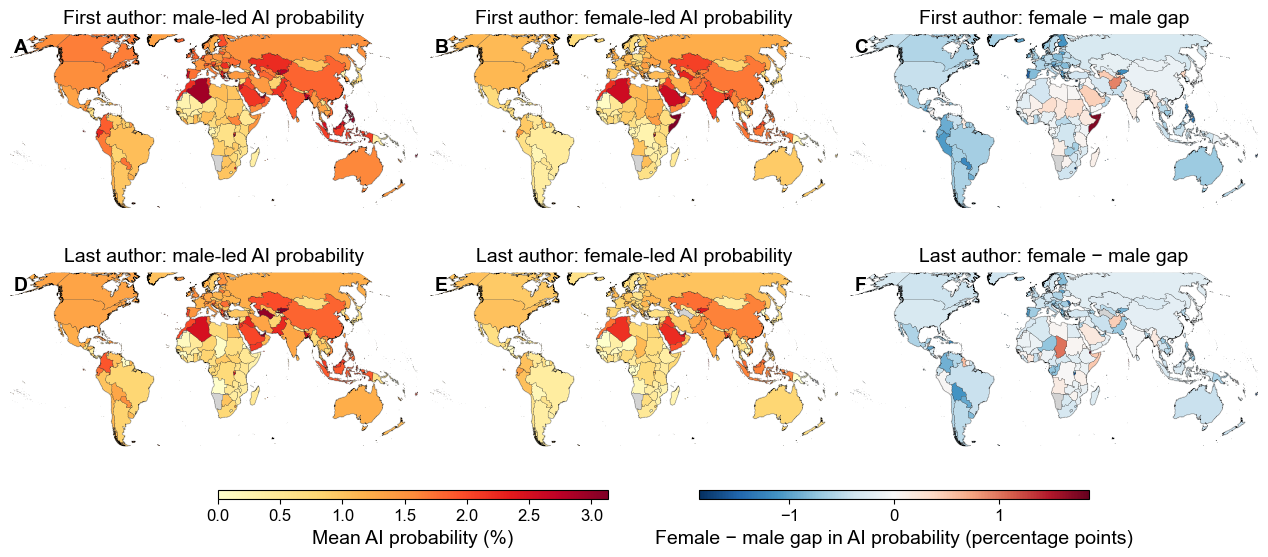

In [10]:
# -----------------------
# Figure: 3 rows × 2 cols
# -----------------------

fig = plt.figure(figsize=(13, 5.5))

gs = fig.add_gridspec(
    2,
    3,
    wspace=0.03,
    hspace=0.04
)

axes = []

for i in range(2):
    for j in range(3):
        ax = fig.add_subplot(
            gs[i, j],
            projection=ccrs.Robinson()
        )
        axes.append(ax)


# Row 1: First author
plot_world_panel(
    axes[0],
    world_first,
    "male_AIProb_pct",
    "First author: male-led AI probability",
    seq_cmap,
    seq_norm
)

plot_world_panel(
    axes[1],
    world_first,
    "female_AIProb_pct",
    "First author: female-led AI probability",
    seq_cmap,
    seq_norm
)

plot_world_panel(
    axes[2],
    world_first,
    "gap_pct",
    "First author: female − male gap",
    gap_cmap,
    gap_norm
)


# Row 2: Last author
plot_world_panel(
    axes[3],
    world_last,
    "male_AIProb_pct",
    "Last author: male-led AI probability",
    seq_cmap,
    seq_norm
)

plot_world_panel(
    axes[4],
    world_last,
    "female_AIProb_pct",
    "Last author: female-led AI probability",
    seq_cmap,
    seq_norm
)

plot_world_panel(
    axes[5],
    world_last,
    "gap_pct",
    "Last author: female − male gap",
    gap_cmap,
    gap_norm
)



# -----------------------
# Colorbars
# -----------------------

cax1 = fig.add_axes([0.18, 0.055, 0.30, 0.015])
cb1 = mpl.colorbar.ColorbarBase(
    cax1,
    cmap=seq_cmap,
    norm=seq_norm,
    orientation="horizontal"
)

cb1.set_label(
    "Mean AI probability (%)"
)

cb1.ax.tick_params()


cax2 = fig.add_axes([0.55, 0.055, 0.30, 0.015])
cb2 = mpl.colorbar.ColorbarBase(
    cax2,
    cmap=gap_cmap,
    norm=gap_norm,
    orientation="horizontal"
)

cb2.set_label(
    "Female − male gap in AI probability (percentage points)"
)



# -----------------------
# Panel labels
# -----------------------

for ax, label in zip(axes, list("ABCDEF")):
    ax.text(
        0.01,
        0.98,
        label,
        transform=ax.transAxes,
        fontweight="bold",
        va="top",
        ha="left"
    )


plt.subplots_adjust(
    left=0.02,
    right=0.98,
    top=0.95,
    bottom=0.10
)

plt.savefig("Data/fig3_country.pdf", bbox_inches="tight")

In [12]:
# # -----------------------
# # Figure: 3 rows × 2 cols
# # -----------------------

# fig = plt.figure(figsize=(13, 7))

# gs = fig.add_gridspec(
#     3,
#     2,
#     wspace=0.03,
#     hspace=0.3
# )

# axes = []

# for i in range(3):
#     for j in range(2):
#         ax = fig.add_subplot(
#             gs[i, j],
#             projection=ccrs.Robinson()
#         )
#         axes.append(ax)


# # Row 1: Male-led AI probability
# plot_world_panel(
#     axes[0],
#     world_first,
#     "male_AIProb_pct",
#     "First author: male-led AI probability",
#     seq_cmap,
#     seq_norm
# )

# plot_world_panel(
#     axes[1],
#     world_last,
#     "male_AIProb_pct",
#     "Last author: male-led AI probability",
#     seq_cmap,
#     seq_norm
# )


# # Row 2: Female-led AI probability
# plot_world_panel(
#     axes[2],
#     world_first,
#     "female_AIProb_pct",
#     "First author: female-led AI probability",
#     seq_cmap,
#     seq_norm
# )

# plot_world_panel(
#     axes[3],
#     world_last,
#     "female_AIProb_pct",
#     "Last author: female-led AI probability",
#     seq_cmap,
#     seq_norm
# )


# # Row 3: Female − male gap
# plot_world_panel(
#     axes[4],
#     world_first,
#     "gap_pct",
#     "First author: female − male gap",
#     gap_cmap,
#     gap_norm
# )

# plot_world_panel(
#     axes[5],
#     world_last,
#     "gap_pct",
#     "Last author: female − male gap",
#     gap_cmap,
#     gap_norm
# )


# # -----------------------
# # Colorbars
# # -----------------------

# cax1 = fig.add_axes([0.18, 0.055, 0.30, 0.015])
# cb1 = mpl.colorbar.ColorbarBase(
#     cax1,
#     cmap=seq_cmap,
#     norm=seq_norm,
#     orientation="horizontal"
# )

# cb1.set_label(
#     "Mean AI probability (%)"
# )

# cb1.ax.tick_params()


# cax2 = fig.add_axes([0.55, 0.055, 0.30, 0.015])
# cb2 = mpl.colorbar.ColorbarBase(
#     cax2,
#     cmap=gap_cmap,
#     norm=gap_norm,
#     orientation="horizontal"
# )

# cb2.set_label(
#     "Female − male gap in AI probability (percentage points)"
# )



# # -----------------------
# # Panel labels
# # -----------------------

# for ax, label in zip(axes, list("ABCDEF")):
#     ax.text(
#         0.01,
#         0.98,
#         label,
#         transform=ax.transAxes,
#         fontweight="bold",
#         va="top",
#         ha="left"
#     )


# plt.subplots_adjust(
#     left=0.02,
#     right=0.98,
#     top=0.95,
#     bottom=0.10
# )

# plt.savefig("Data/fig3_country.pdf", bbox_inches="tight")